# Units, quantities, and masks

SpectroChemPy uses Pint for units and NumPy masked arrays for excluded values, while
keeping the original Pint and NumPy objects available from the public ``scp``
namespace. This guide explains the SpectroChemPy-facing contract. The lower-level
libraries remain the authority for functionality not described here.

In [1]:
import spectrochempy as scp

## Units, quantities, and the registry

``scp.ur`` is the unit registry configured by SpectroChemPy. It contains standard
Pint units together with project definitions and formatting, including absorbance,
Kubelka--Munk, transmittance, and ppm. Public objects created through ``scp.Unit``,
``scp.Quantity``, or ``scp.ur`` use this registry.

``Unit`` describes a unit without a value. ``Quantity`` associates a scalar or array
magnitude with a unit. The following public constructions are equivalent and
registry-compatible:

In [2]:
length_unit = scp.Unit("cm")
first = scp.Quantity(2.5, "cm")
second = 2.5 * scp.ur.cm
third = scp.ur.Quantity(2.5, "cm")

print("Unit:", length_unit)
print("Equivalent quantities:", first, second, third)

Unit: cm
Equivalent quantities: 2.5 cm 2.5 cm 2.5 cm


A ``Quantity`` carries a magnitude and units, but no named dimensions,
coordinates, metadata, mask policy, or processing history. An ``NDDataset`` owns
those spectroscopy-oriented structures and stores its unit separately:

In [3]:
wavenumber = scp.Coord(
    [1000.0, 1100.0, 1200.0],
    title="wavenumber",
    units="cm^-1",
)
spectrum = scp.NDDataset(
    [0.25, 2.00, 0.75],
    coordset=[wavenumber],
    dims=["x"],
    title="absorbance",
    units="absorbance",
)

spectrum, spectrum.values

(NDDataset: [float64] a.u. (size: 3),
 Quantity(array([    0.25,        2,     0.75]), "absorbance"))

Compatible arithmetic converts the right-hand operand to the left-hand unit. These
ordinary arithmetic operations return new objects and leave their operands unchanged.

In [4]:
total = 1.0 * scp.ur.cm + 5.0 * scp.ur.mm
shifted = scp.NDDataset([1.0, 2.0], units="cm") + 5.0 * scp.ur.mm

total, shifted

(Quantity(1.5, "centimeter"), NDDataset: [float64] cm (size: 2))

### Conversions and mutation

``Quantity.to()`` and ``NDDataset.to()`` create converted objects. ``ito()`` converts
in place and returns ``None``. The examples below show the original and converted
objects side by side.

In [5]:
distance = 2500.0 * scp.ur.nm
distance_um = distance.to("um")
print("Original:", distance)
print("Converted copy:", distance_um)

Original: 2500.0 nm
Converted copy: 2.5 μm


In [6]:
mutable_distance = distance.copy()
returned = mutable_distance.ito("um")
print("In-place result:", mutable_distance)
print("Return value:", returned)

In-place result: 2.5 μm
Return value: None


In [7]:
wavelengths = scp.NDDataset([1000.0, 2000.0], units="nm")
wavelengths_um = wavelengths.to("um")
print("Original:", wavelengths)
print("Converted copy:", wavelengths_um)

Original: NDDataset: [float64] nm (size: 2)
Converted copy: NDDataset: [float64] μm (size: 2)


In [8]:
mutable_wavelengths = wavelengths.copy()
returned = mutable_wavelengths.ito("um")
print("In-place result:", mutable_wavelengths)
print("Return value:", returned)

In-place result: NDDataset: [float64] μm (size: 2)
Return value: None


SpectroChemPy enables Pint's spectroscopy, Boltzmann, and chemistry contexts.
Consequently, converting wavenumber to wavelength is a physical equivalence supplied
by the spectroscopy context, not a plain conversion between dimensions:

In [9]:
band_position = 1000.0 * scp.ur("cm^-1")
wavelength = band_position.to("um")
wavelength

Quantity(10.0, "micrometer")

Incompatible dimensions raise the original Pint ``DimensionalityError``, re-exported
as ``scp.DimensionalityError``. Catch that public exception when incompatibility is an
expected branch of the workflow:

In [10]:
try:
    (1.0 * scp.ur.meter).to("second")
except scp.DimensionalityError as error:
    incompatibility = str(error)

incompatibility

"Cannot convert from 'meter' ([length]) to 'second' ([time])"

Dimensionless values still carry a dimensionless unit. Percent is a scaled
dimensionless unit: 50 percent corresponds to the fraction 0.5.

In [11]:
fraction = (50.0 * scp.ur.percent).to("dimensionless")
percentage = (0.5 * scp.ur.dimensionless).to("percent")
fraction, percentage

(Quantity(0.5, "dimensionless"), Quantity(50.0, "percent"))

## Masks on NDDataset

Assigning ``scp.MASKED`` excludes a value without deleting it. The data shape and
coordinate remain unchanged, while ``mask`` records the excluded position and
``masked_data`` presents a NumPy masked-array view of the values.

In [12]:
masked = spectrum.copy()
masked.meta.source = "synthetic example"
mean_before = scp.mean(masked)
masked[1] = scp.MASKED
mean_after = scp.mean(masked)

print("Stored values:", masked.data)
print("Mask:", masked.mask)
print("Mean before masking:", mean_before)
print("Mean after masking:", mean_after)

Stored values: [    0.25        2     0.75]
Mask: [  False   True   False]
Mean before masking: 1.0 a.u.
Mean after masking: 0.5 a.u.


SpectroChemPy calculations preserve the mask. Reductions such as ``mean`` ignore the
masked value; coordinates and metadata stay attached to dataset results when the
operation retains them.

In [13]:
offset = masked + 0.1 * scp.ur.absorbance
print("Offset values:", offset.masked_data)
print("Mean after offset:", scp.mean(offset))

Offset values: [    0.35   --     0.85]
Mean after offset: 0.6 a.u.


A longer signal makes the plotting behavior easier to see. The original signal is
shown in gray. The masked copy is superimposed in blue, with the excluded interval
highlighted. The blue line stops on each side of that interval: the plot does not
interpolate across masked values. The gray curve remains visible there only as a
reference for the stored original signal.

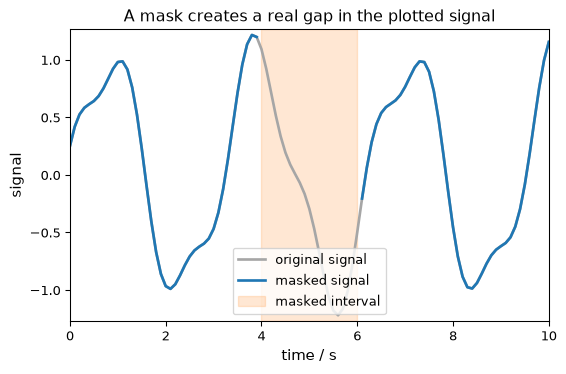

In [14]:
time = scp.Coord.linspace(0.0, 10.0, 101, title="time", units="s")
original_signal = scp.NDDataset(
    scp.sin(2.0 * time.data) + 0.25 * scp.cos(5.0 * time.data),
    coordset=[time],
    dims=["x"],
    title="signal",
)
masked_signal = original_signal.copy()
masked_signal[40:61] = scp.MASKED

ax = original_signal.plot(
    color="0.65",
    linewidth=2,
    label="original signal",
    show=False,
)
_ = masked_signal.plot(
    ax=ax,
    clear=False,
    color="tab:blue",
    linewidth=2,
    label="masked signal",
    show=False,
)
_ = ax.axvspan(4.0, 6.0, color="tab:orange", alpha=0.18, label="masked interval")
_ = ax.set_title("A mask creates a real gap in the plotted signal")
_ = ax.legend()

``scp.NOMASK`` is the NumPy sentinel returned when no value is masked. To remove an
existing mask through the public dataset API, call ``remove_masks()``. This operation
mutates the dataset, returns ``None``, and reveals the still-stored value; it does not
recreate a deleted point.

In [15]:
returned = masked.remove_masks()
print("Restored value:", masked.data[1])
print("Shape preserved:", masked.shape)
print("Mask after removal:", masked.mask)
print("Return value:", returned)

Restored value: 2.0
Shape preserved: (3,)
Mask after removal: False
Return value: None


### Masked values are not NaN values

A NaN remains an unmasked numerical value. It propagates through the tested mean,
whereas the explicitly masked value is excluded. Neither operation removes a
coordinate or changes the dataset length.

In [16]:
nan_spectrum = scp.NDDataset(
    [0.25, float("nan"), 0.75],
    coordset=[wavenumber.copy()],
    dims=["x"],
    units="absorbance",
)
masked_again = spectrum.copy()
masked_again[1] = scp.MASKED

print("Mean with NaN:", scp.mean(nan_spectrum))
print("Mean with a mask:", scp.mean(masked_again))
print("Both datasets keep", nan_spectrum.size, "positions")

Mean with NaN: nan a.u.
Mean with a mask: 0.5 a.u.
Both datasets keep 3 positions


### Interoperability with raw arrays

Use ``NDDataset`` in normal SpectroChemPy workflows. Raw accessors deliberately carry
less information:

- ``data`` is an unmasked NumPy array; the dataset's units, coordinates, metadata,
  and mask are separate and are not attached to that array;
- ``masked_data`` and ``to_array()`` are NumPy ``MaskedArray`` objects that preserve
  the mask, but not units, coordinates, or metadata;
- ``values`` is a Pint ``Quantity`` whose magnitude preserves the mask and whose unit
  is retained, but it has no SpectroChemPy coordinates or metadata.

``scp.MaskedArray`` and ``scp.MaskedConstant`` are the original NumPy types exposed
for interoperability. ``scp.MASKED`` is an instance of ``MaskedConstant``; they are
not replacements for ``NDDataset``.

In [17]:
raw_data = masked_again.data
masked_data = masked_again.masked_data
quantity_values = masked_again.values
array_copy = masked_again.to_array()

print("data:", type(raw_data).__name__, "(mask and units separate)")
print("masked_data:", type(masked_data).__name__, "(mask retained)")
print("values:", type(quantity_values).__name__, "(mask and units retained)")
print("to_array():", type(array_copy).__name__, "(mask retained)")
print("MASKED:", type(scp.MASKED).__name__)

data: ndarray (mask and units separate)
masked_data: MaskedArray (mask retained)
values: Quantity (mask and units retained)
to_array(): MaskedArray (mask retained)
MASKED: MaskedConstant


## Identity and further help

SpectroChemPy intentionally preserves the Pint registry, classes, exception, and the
NumPy sentinels and masked-array classes. Therefore ``help(scp.Quantity)`` or
``help(scp.MaskedArray)`` can continue to show documentation from the originating
library.